In [102]:
import numpy as np
from io import StringIO

# proliferating e-anyons, m-anyons subthreshold

data_str1 = """0.162375 0.256875 0.347000 0.455250 0.571875 0.676750 0.756250 0.830375
0.170625 0.251750 0.360250 0.474250 0.572625 0.667125 0.763375 0.823750
0.164875 0.249250 0.347125 0.456250 0.572625 0.676250 0.750750 0.830000
0.168250 0.256750 0.355500 0.466250 0.568750 0.677750 0.757625 0.824375
0.121500 0.205750 0.318750 0.446625 0.566375 0.680500 0.784000 0.843000
0.120375 0.207125 0.317125 0.447125 0.568625 0.679500 0.778250 0.845000
0.125125 0.200250 0.316500 0.445250 0.568375 0.681125 0.768250 0.848500
0.116125 0.205750 0.305375 0.442375 0.559500 0.690250 0.787500 0.846750
0.087125 0.166250 0.288875 0.418125 0.564125 0.692625 0.796125 0.867125
0.084875 0.164625 0.281250 0.420625 0.558125 0.696750 0.796875 0.863750
0.090375 0.167500 0.280375 0.423375 0.558750 0.693875 0.803000 0.875750
0.084375 0.167000 0.284625 0.416000 0.566250 0.691875 0.797750 0.865750
0.061750 0.137375 0.254375 0.404500 0.562625 0.696875 0.809250 0.890125
0.060750 0.137000 0.261500 0.402250 0.554375 0.704500 0.813375 0.886125
0.067000 0.140250 0.250375 0.393750 0.566250 0.705625 0.813375 0.895250
0.060875 0.135000 0.249625 0.398250 0.557250 0.695625 0.813500 0.882000"""
data_str2 = """0.168375 0.246250 0.356125 0.459750 0.581625 0.660625 0.760375 0.822875
0.171125 0.251625 0.353000 0.465125 0.579375 0.660375 0.757750 0.830000
0.164375 0.260000 0.351375 0.460000 0.578125 0.683250 0.753250 0.823500
0.165750 0.244750 0.352125 0.468500 0.579875 0.664750 0.757125 0.823000
0.120000 0.211625 0.312125 0.449125 0.568875 0.678000 0.771875 0.849000
0.118875 0.206375 0.320625 0.453375 0.558500 0.685500 0.782000 0.844750
0.124875 0.208000 0.316750 0.433500 0.569375 0.674375 0.768000 0.853375
0.120125 0.202625 0.322625 0.441125 0.567875 0.677875 0.783500 0.851250
0.081250 0.167125 0.272375 0.423375 0.566250 0.704625 0.796625 0.874500
0.084500 0.166125 0.274250 0.426500 0.573375 0.700375 0.804875 0.876375
0.087125 0.172875 0.286625 0.420875 0.565750 0.695625 0.794625 0.871000
0.085375 0.161500 0.281125 0.420375 0.573125 0.694500 0.794750 0.870000
0.067000 0.138875 0.259250 0.398500 0.545875 0.706875 0.817750 0.890000
0.061625 0.142750 0.250000 0.397000 0.553625 0.707125 0.820250 0.888000
0.062000 0.132500 0.246125 0.386625 0.566750 0.701125 0.809750 0.886625
0.064500 0.136375 0.253250 0.407500 0.560750 0.698750 0.810000 0.887750 """
data_str3 = """ 0.166750 0.251875 0.351625 0.460000 0.579000 0.680250 0.755250 0.819875
0.174750 0.241750 0.356875 0.463625 0.575250 0.680750 0.765000 0.825375
0.160125 0.245875 0.350375 0.477000 0.575750 0.676250 0.759750 0.820000
0.168375 0.252250 0.344500 0.469250 0.582250 0.667375 0.757625 0.823250
0.119750 0.200875 0.316250 0.447000 0.572375 0.689375 0.772500 0.848875
0.121375 0.205750 0.320500 0.429875 0.563375 0.686125 0.781125 0.854000
0.122250 0.206000 0.318250 0.442875 0.573625 0.695750 0.768375 0.847750
0.112500 0.204625 0.317875 0.438750 0.566750 0.685000 0.773875 0.855500
0.089875 0.163000 0.279250 0.414750 0.565625 0.692625 0.799625 0.864000
0.085000 0.163125 0.283375 0.422750 0.566750 0.697000 0.795125 0.872875
0.088875 0.164625 0.269125 0.420500 0.561250 0.701500 0.802375 0.866000
0.087000 0.171750 0.281625 0.425625 0.562875 0.696625 0.803500 0.868000
0.065125 0.136500 0.254750 0.402125 0.563750 0.703250 0.814375 0.890125
0.069875 0.130000 0.249500 0.393250 0.562250 0.709875 0.810375 0.886875
0.066875 0.134375 0.246750 0.388375 0.566750 0.696250 0.817375 0.880625
0.060375 0.144875 0.241000 0.397875 0.560625 0.701500 0.802875 0.885000 """
# data_str4 = """ 0.160500 0.250750 0.350000 0.468875 0.568375 0.666625 0.764000 0.823875
# 0.168125 0.250750 0.355625 0.458500 0.575125 0.680000 0.756875 0.831250
# 0.163000 0.254000 0.350375 0.468000 0.575375 0.669125 0.752875 0.822750
# 0.171625 0.250250 0.355250 0.477625 0.574500 0.674375 0.754250 0.830875
# 0.120250 0.214125 0.314500 0.446125 0.565500 0.679125 0.786875 0.848500
# 0.121000 0.202000 0.311000 0.436375 0.570875 0.685250 0.776500 0.844125
# 0.119375 0.200500 0.315125 0.440750 0.576375 0.680375 0.775625 0.846375
# 0.121000 0.202375 0.322125 0.441750 0.568750 0.682500 0.780875 0.859625
# 0.091250 0.167875 0.281250 0.429375 0.568000 0.693750 0.792375 0.871500
# 0.090875 0.156625 0.280375 0.425000 0.558625 0.704000 0.794750 0.874750
# 0.087875 0.174875 0.280000 0.425125 0.566125 0.695750 0.796875 0.868000
# 0.091500 0.172875 0.285625 0.418875 0.569125 0.691250 0.797000 0.873875
# 0.061125 0.134000 0.264375 0.406625 0.572375 0.701375 0.813500 0.888375
# 0.064000 0.142125 0.257875 0.413375 0.559125 0.704125 0.816750 0.884500
# 0.065000 0.142750 0.251000 0.406000 0.564750 0.709750 0.815250 0.885125
# 0.064875 0.138000 0.255500 0.404375 0.563500 0.714875 0.815750 0.892750 """
# data_str5 = """ 0.597900 0.618200 0.655800 0.664000 0.682400 0.713800 0.719300 0.734800
# 0.603400 0.619600 0.637600 0.671000 0.681100 0.701600 0.725300 0.741100
# 0.600700 0.627800 0.652000 0.661300 0.684900 0.698200 0.719300 0.734800
# 0.599600 0.621600 0.645900 0.666600 0.686500 0.705300 0.715700 0.730200
# 0.596100 0.610700 0.641000 0.681500 0.689700 0.710100 0.734600 0.745400
# 0.599700 0.627500 0.644500 0.661100 0.692000 0.713800 0.725500 0.745600
# 0.599500 0.614700 0.643400 0.665300 0.688400 0.708300 0.725500 0.746700
# 0.593900 0.619900 0.640400 0.670200 0.687600 0.707600 0.729500 0.746500
# 0.589700 0.621800 0.642200 0.673200 0.690300 0.718900 0.736400 0.759600
# 0.601400 0.620400 0.644200 0.672400 0.699000 0.708500 0.743900 0.763800
# 0.595900 0.625900 0.647300 0.666300 0.696100 0.706100 0.738300 0.757200
# 0.593800 0.616700 0.646500 0.657900 0.697900 0.717800 0.744300 0.762800
# 0.601200 0.615200 0.652300 0.671800 0.705400 0.731000 0.749800 0.769300
# 0.588200 0.622000 0.647100 0.675700 0.701300 0.724000 0.743000 0.769500
# 0.589900 0.615000 0.642900 0.676700 0.699600 0.732200 0.753000 0.776500
# 0.590300 0.612700 0.642700 0.674200 0.695800 0.727300 0.742800 0.772500 """
# data_str6 = """ 0.608100 0.631000 0.647000 0.667500 0.682500 0.704100 0.718600 0.736200
# 0.604800 0.619300 0.642900 0.661800 0.681200 0.691700 0.719500 0.742200
# 0.599600 0.629000 0.643300 0.659400 0.683300 0.698100 0.723100 0.744100
# 0.598900 0.629000 0.656200 0.671500 0.679300 0.695300 0.717900 0.728800
# 0.604900 0.620800 0.638200 0.665700 0.696400 0.712500 0.734000 0.745300
# 0.596000 0.620800 0.634800 0.669100 0.693100 0.702800 0.726100 0.744500
# 0.600000 0.616700 0.641000 0.667800 0.685600 0.704200 0.723300 0.748200
# 0.593500 0.620100 0.645200 0.665500 0.690600 0.708600 0.737600 0.747600
# 0.588700 0.607300 0.644500 0.676500 0.697100 0.717800 0.744500 0.759600
# 0.582400 0.614600 0.642800 0.668700 0.694900 0.716500 0.741100 0.765000
# 0.593400 0.619700 0.647200 0.672300 0.693700 0.720100 0.737700 0.758300
# 0.582300 0.616600 0.643500 0.667800 0.702800 0.718800 0.738800 0.762000
# 0.591500 0.620600 0.642700 0.672000 0.704300 0.727200 0.747100 0.776500
# 0.589800 0.619500 0.651000 0.675500 0.701200 0.726200 0.759200 0.777700
# 0.578900 0.617000 0.650000 0.677000 0.701000 0.729100 0.748900 0.774700
# 0.592700 0.613200 0.641800 0.672300 0.693700 0.726800 0.753800 0.778400 """
# data_str7 = """ 0.611200 0.617200 0.645300 0.662500 0.689700 0.715600 0.724700 0.737000
# 0.609900 0.623600 0.640500 0.664500 0.684200 0.700200 0.715800 0.726500
# 0.609100 0.627700 0.642100 0.661100 0.678100 0.697200 0.720700 0.737300
# 0.604300 0.621700 0.653100 0.663600 0.686400 0.700000 0.718700 0.731500
# 0.606900 0.627400 0.645400 0.659700 0.690900 0.708700 0.728800 0.736600
# 0.608000 0.630600 0.640800 0.667300 0.684500 0.706000 0.731100 0.738100
# 0.597600 0.620900 0.637200 0.665200 0.694000 0.710900 0.728700 0.757200
# 0.598700 0.616300 0.639500 0.666000 0.691000 0.703500 0.724800 0.746300
# 0.594700 0.626300 0.643700 0.674900 0.691500 0.718000 0.746300 0.756800
# 0.594700 0.611500 0.646100 0.673600 0.696300 0.714500 0.734600 0.766400
# 0.598700 0.615000 0.643000 0.669600 0.696800 0.722100 0.742800 0.759300
# 0.584700 0.620400 0.656300 0.664400 0.687000 0.711000 0.741800 0.762000
# 0.589900 0.613500 0.648400 0.669400 0.703600 0.727500 0.750200 0.772000
# 0.583200 0.623100 0.644400 0.676200 0.705000 0.723200 0.746600 0.771300
# 0.583100 0.613700 0.649000 0.675500 0.700600 0.731700 0.743600 0.775200
# 0.582900 0.618300 0.639900 0.666000 0.700000 0.733700 0.751500 0.770700 """
# data_str8 = """ 0.602000 0.627500 0.641800 0.662200 0.685900 0.700500 0.724000 0.725700
# 0.597800 0.633500 0.656000 0.666500 0.680900 0.699500 0.726400 0.738100
# 0.602600 0.617800 0.645700 0.658800 0.692900 0.695600 0.714000 0.728300
# 0.609900 0.627400 0.651800 0.661200 0.679300 0.704800 0.715500 0.732900
# 0.601900 0.621400 0.651200 0.656500 0.684500 0.712400 0.729000 0.757500
# 0.592200 0.623000 0.644600 0.662600 0.686400 0.701400 0.732600 0.741300
# 0.588300 0.621100 0.647300 0.655800 0.688700 0.709400 0.726600 0.742100
# 0.593400 0.622600 0.649100 0.663500 0.695900 0.711300 0.732300 0.749300
# 0.584800 0.610800 0.651100 0.675100 0.690200 0.715300 0.732900 0.761300
# 0.596600 0.621000 0.639400 0.670600 0.696900 0.718200 0.734700 0.758800
# 0.600400 0.624900 0.637100 0.666300 0.696000 0.713900 0.735300 0.752200
# 0.589300 0.612400 0.641800 0.677300 0.695000 0.718900 0.738500 0.769600
# 0.590800 0.618400 0.648300 0.676700 0.704700 0.724200 0.746200 0.774000
# 0.587600 0.606200 0.651300 0.686500 0.695600 0.726800 0.751000 0.774600
# 0.590700 0.614100 0.662300 0.680200 0.695600 0.727300 0.751300 0.781600
# 0.586800 0.619400 0.639800 0.677100 0.696200 0.726600 0.746900 0.764900 """
# data_str9 = """ 0.603200 0.632000 0.643400 0.660800 0.682100 0.699400 0.720600 0.735100
# 0.615400 0.619200 0.640800 0.670600 0.673200 0.700100 0.719600 0.727200
# 0.599100 0.622600 0.640700 0.660800 0.674400 0.695200 0.718400 0.742000
# 0.604700 0.615600 0.639600 0.652800 0.684200 0.706400 0.715100 0.727300
# 0.596000 0.619900 0.644700 0.668100 0.691100 0.701700 0.730000 0.751400
# 0.596000 0.619900 0.651900 0.674000 0.685400 0.702300 0.734000 0.743700
# 0.589500 0.614400 0.643600 0.672300 0.691900 0.703300 0.734600 0.755400
# 0.591500 0.616500 0.644300 0.657100 0.688500 0.711200 0.726900 0.751600
# 0.588700 0.625400 0.637800 0.683000 0.696300 0.713100 0.740600 0.757900
# 0.596100 0.619000 0.646400 0.668500 0.699400 0.714400 0.743500 0.758700
# 0.593800 0.624700 0.632400 0.680700 0.692300 0.716600 0.744700 0.756900
# 0.603700 0.618900 0.642900 0.668600 0.691600 0.723500 0.750000 0.760700
# 0.594800 0.619600 0.649800 0.673500 0.701300 0.731900 0.754500 0.775600
# 0.588200 0.622000 0.648900 0.674300 0.705300 0.727600 0.755400 0.775600
# 0.584800 0.620900 0.647000 0.678000 0.704400 0.722800 0.745000 0.766600
# 0.592100 0.624000 0.652100 0.673800 0.694100 0.726300 0.750500 0.773500 """
# data_str10= """ 0.603600 0.629900 0.630700 0.659800 0.686600 0.694700 0.722800 0.738600
# 0.603600 0.629900 0.648800 0.665000 0.686600 0.695900 0.715700 0.737300
# 0.600600 0.626800 0.644800 0.656700 0.685900 0.707100 0.722400 0.735500
# 0.599400 0.623500 0.630700 0.659800 0.683900 0.708100 0.714000 0.730500
# 0.603900 0.619600 0.643300 0.667500 0.687500 0.700300 0.723200 0.752100
# 0.602400 0.625300 0.648100 0.673200 0.682000 0.707500 0.734200 0.749400
# 0.601600 0.624700 0.649400 0.660400 0.694800 0.716600 0.731400 0.747700
# 0.601600 0.624700 0.636400 0.668400 0.685900 0.712600 0.722300 0.746300
# 0.594400 0.625600 0.651500 0.671900 0.696200 0.710600 0.740900 0.760800
# 0.597200 0.619500 0.641500 0.670500 0.694900 0.715000 0.741600 0.761000
# 0.590900 0.623700 0.644500 0.669400 0.691800 0.713800 0.731100 0.754700
# 0.600300 0.618000 0.643500 0.667500 0.699300 0.719100 0.735200 0.753000
# 0.584900 0.618900 0.643500 0.673400 0.697400 0.730000 0.748300 0.779900
# 0.585800 0.617700 0.645000 0.677500 0.696200 0.723800 0.753100 0.773400
# 0.589700 0.612300 0.646000 0.672800 0.700800 0.726900 0.749700 0.774100
# 0.590100 0.619400 0.643900 0.674100 0.695000 0.727800 0.751600 0.770800 """

run1 = np.loadtxt(StringIO(data_str1))
run2 = np.loadtxt(StringIO(data_str2))
run3 = np.loadtxt(StringIO(data_str3))
# run4 = np.loadtxt(StringIO(data_str4))
# run5 = np.loadtxt(StringIO(data_str5))
# run6 = np.loadtxt(StringIO(data_str6))
# run7 = np.loadtxt(StringIO(data_str7))
# run8 = np.loadtxt(StringIO(data_str8))
# run9 = np.loadtxt(StringIO(data_str9))
# run10= np.loadtxt(StringIO(data_str10))

runs = np.stack([run1, run2, run3]) #, run2, run3, run4, run5, run6, run7, run8, run9, run10

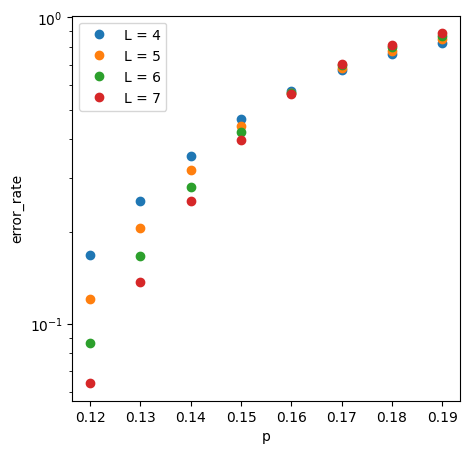

In [103]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

p = [0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19]
L = [4, 5, 6, 7]

error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

plt.figure(figsize=(5, 5))
for l in range(len(L)):
    plt.plot(p, error_rate[l], 'o', label=f'L = {L[l]}')
    
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('error_rate')
plt.legend()
plt.show()

In [104]:
from scipy.optimize import curve_fit

p = np.tile(np.array([0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19]), 4)
L = np.repeat(np.array([4,5,6,7]), 8)
rate = error_rate.flatten()
n = 8000
rate_error = np.array([])
for i in range(len(p)):
    se = (rate[i]*(1-rate[i])/n)**(1/2)
    rate_error = np.append(rate_error, se)

In [105]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [ 0.16534915  2.42991339  0.60917537  5.48069134 -1.59828272]
Parameter standard deviations: [0.00097772 0.08155524 0.01070935 0.12977674 0.41521571]


np.float64(134.8070608695357)

In [106]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0], full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [  0.16232905   1.50089316   0.59282285   4.1280705   -5.83057783
 -67.25892683]
Parameter standard deviations: [6.96413143e-04 5.05568048e-02 8.77732507e-03 1.43095396e-01
 7.35500777e-01 7.26944168e+00]


np.float64(18.038371932287482)

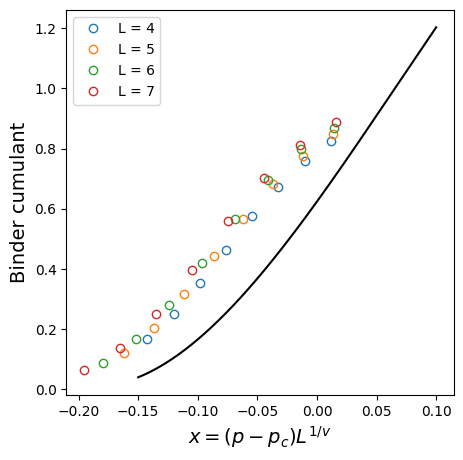

In [107]:
pc, nu, A, B, C, D = 0.16472135,   1.76020476,   0.62380722,   5.48805823,   6.04357426, -30.74726193

p = [0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17]
L = [4, 5, 6, 7]
error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

x = np.zeros((len(L), len(p)))
plt.figure(figsize=(5, 5))
for l in range(len(L)):
    for i in range(len(p)):
        x[l][i] = (p[i]-pc) * (L[l]**(1/nu))
    plt.plot(x[l], error_rate[l], 'o', markerfacecolor='none', label=f'L = {L[l]}')
x_data = np.linspace(-0.15, 0.1, 1000)
y_data = A + B*x_data + C*(x_data**2) + D*(x_data**3)
plt.plot(x_data, y_data, color = 'k')

#ax = plt.gca()
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

#plt.yscale('log')
plt.xlabel('$x=(p-p_c)L^{1/v}$', fontsize=14)
plt.ylabel('Binder cumulant', fontsize=14)
plt.legend()
#plt.savefig('modified-D4.png', dpi=600, bbox_inches='tight')
plt.show()

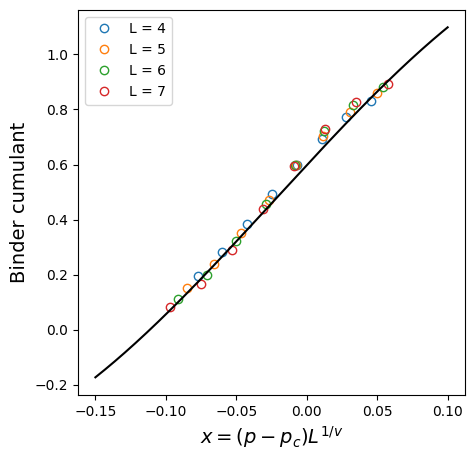

In [101]:
pc, nu, A, B, C = 0.1640476, 2.45232855, 0.59784903, 5.51835373, -2.07363338

p = [0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19]
L = [4, 5, 6, 7]
error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

x = np.zeros((len(L), len(p)))
plt.figure(figsize=(5, 5))
for l in range(len(L)):
    for i in range(len(p)):
        x[l][i] = (p[i]-pc) * (L[l]**(1/nu))
    plt.plot(x[l], error_rate[l], 'o', markerfacecolor='none', label=f'L = {L[l]}')
x_data = np.linspace(-0.15, 0.1, 1000)
y_data = A + B*x_data + C*(x_data**2) + D*(x_data**3)
plt.plot(x_data, y_data, color = 'k')

#ax = plt.gca()
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

#plt.yscale('log')
plt.xlabel('$x=(p-p_c)L^{1/v}$', fontsize=14)
plt.ylabel('Binder cumulant', fontsize=14)
plt.legend()
#plt.savefig('modified-D4.png', dpi=600, bbox_inches='tight')
plt.show()